### Importação de Bibliotecas

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Questões

## d) Convolução Linear


Item d) Sinais x[n], h[n] e r[n] plotados e salvos em d_sinais.png.


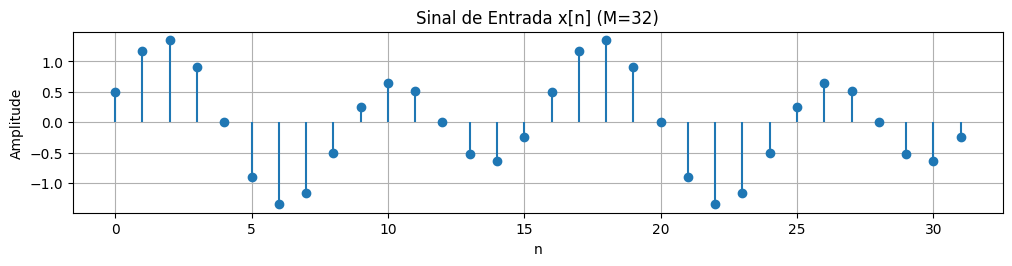

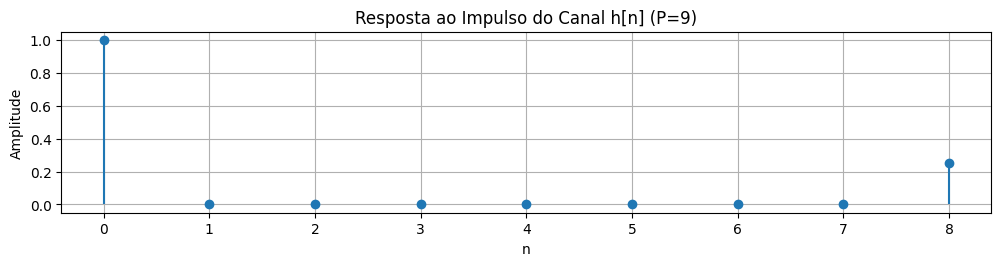

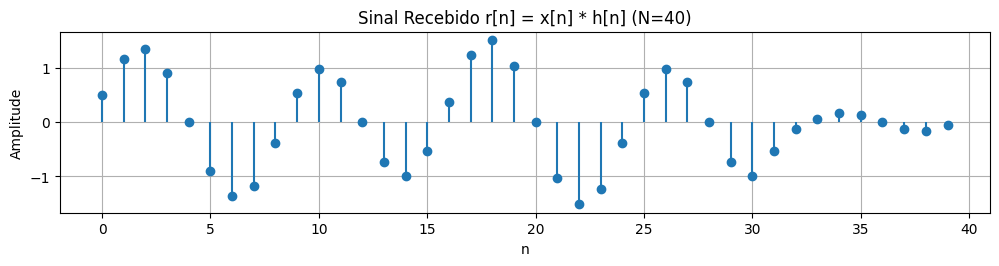

Comprimento de r[n]: 40. Esperado: 40.


In [6]:
# Utilizando a função np.convolve(x,h) da biblioteca NumPy, faça a convolução linear para obter o sinal
# recebido r[n] = x[n] ∗ h[n]. Observe que o comprimento da convolução linear será P + M − 1 = 40. Plote
# o gráfico de cada um dos sinais (x[n], h[n] e r[n]). Como é a forma da distorção introduzida no sinal x[n]
# pelo canal de comunicação?

# --- Parâmetros do Exercício ---
n0 = 8  # Atraso do eco
P = n0 + 1  # Comprimento da resposta ao impulso h[n]
M = 32  # Comprimento do sinal de entrada x[n]
N = M + P - 1  # Comprimento da convolução linear r[n]

# --- Item d) Sinal de Entrada x[n] e Resposta ao Impulso h[n] ---

# 1. Sinal de Entrada x[n]
n_x = np.arange(M)
x = np.sin(np.pi * n_x / 4) + 0.5 * np.cos(np.pi * n_x / 8)

# 2. Resposta ao Impulso do Canal h[n]
h = np.zeros(P)
h[0] = 1.0  # Coeficiente para delta[n]
h[n0] = 0.25  # Coeficiente para 0.25 * delta[n - n0]

# 3. Convolução Linear para obter o sinal recebido r[n]
r = np.convolve(x, h)

print(f"Item d) Sinais x[n], h[n] e r[n] plotados e salvos em d_sinais.png.")

# 4. Plotagem
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.stem(n_x, x, basefmt=" ")
plt.title(f'Sinal de Entrada x[n] (M={M})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 2)
plt.stem(np.arange(P), h, basefmt=" ")
plt.title(f'Resposta ao Impulso do Canal h[n] (P={P})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 3)
plt.stem(np.arange(N), r, basefmt=" ")
plt.title(f'Sinal Recebido r[n] = x[n] * h[n] (N={N})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.savefig('d_sinais.png')
plt.close()
plt.show()

print(f"Comprimento de r[n]: {len(r)}. Esperado: {N}.")

## e) DFT de h[n]

Item e) Módulo e Fase de H[k] plotados e salvos em e_dft_h.png.


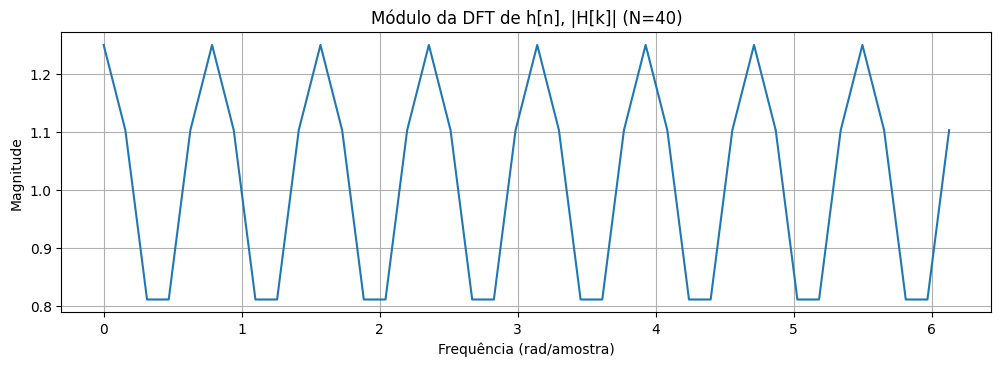

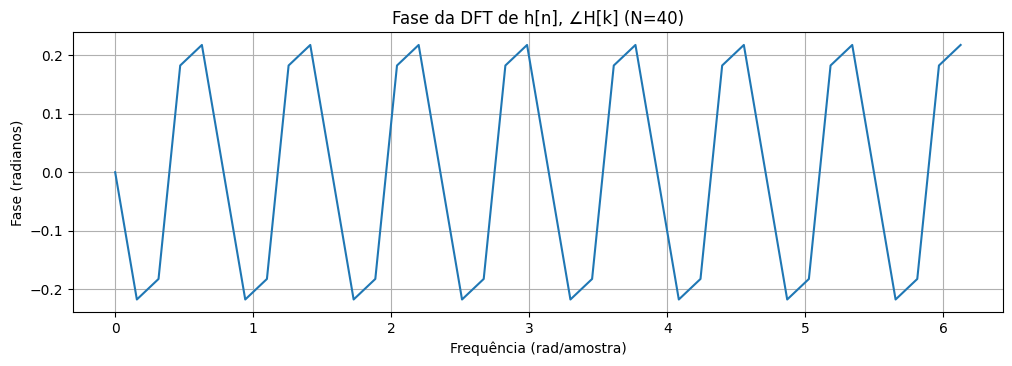

In [7]:
# --- Item e) DFT de h[n] ---

print(f"Item e) Módulo e Fase de H[k] plotados e salvos em e_dft_h.png.")

# 1. Cálculo da DFT de h[n] com N=40 pontos
H_k = np.fft.fft(h, N)

# 2. Plotagem do Módulo e Fase
k_e = np.arange(N)
frequencias = k_e * (2 * np.pi / N) # Frequências em rad/amostra

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(frequencias, np.abs(H_k))
plt.title(f'Módulo da DFT de h[n], |H[k]| (N={N})')
plt.xlabel('Frequência (rad/amostra)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 2)
plt.plot(frequencias, np.angle(H_k))
plt.title(f'Fase da DFT de h[n], ∠H[k] (N={N})')
plt.xlabel('Frequência (rad/amostra)')
plt.ylabel('Fase (radianos)')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.savefig('e_dft_h.png')
plt.close()

## f) Aproximação do Filtro Inverso G[k] e g[n]

Item f) Resposta ao Impulso Aproximada g[n] plotada e salva em f_g_n.png.


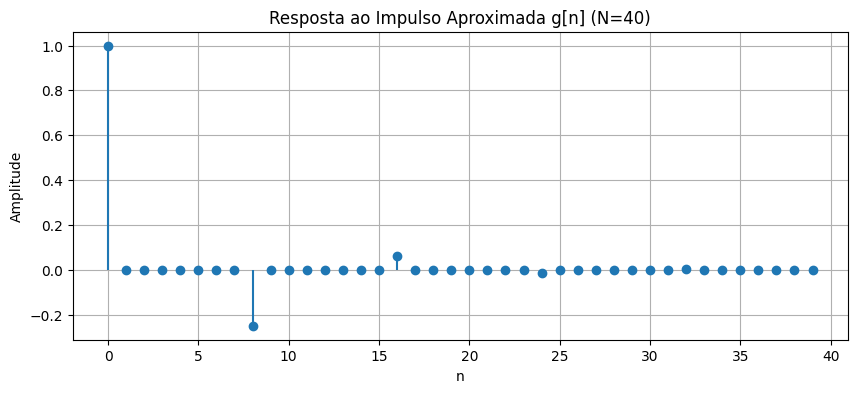

In [8]:
# --- Item f) Aproximação do Filtro Inverso G[k] e g[n] ---

print(f"Item f) Resposta ao Impulso Aproximada g[n] plotada e salva em f_g_n.png.")

# 1. Aproximação do Filtro Inverso G[k] = 1 / H[k]
# Evitar divisão por zero ou números muito pequenos, embora H[k] não deva ser zero
# para um sistema com zero em z=2 (fora do CRU).
G_k = 1.0 / H_k

# 2. Cálculo da Resposta ao Impulso Aproximada g[n]
# Usamos .real para descartar a parte imaginária residual devido a erros de ponto flutuante
g = np.fft.ifft(G_k).real

# 3. Plotagem de g[n]
plt.figure(figsize=(10, 4))
plt.stem(np.arange(N), g, basefmt=" ")
plt.title(f'Resposta ao Impulso Aproximada g[n] (N={N})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.savefig('f_g_n.png')
plt.close()


### g) Comparação com o Filtro Ideal W(z) e w[n]

Item g) Sinais x[n], y_ideal[n] e y_aprox[n] plotados e salvos em g_recuperacao.png.


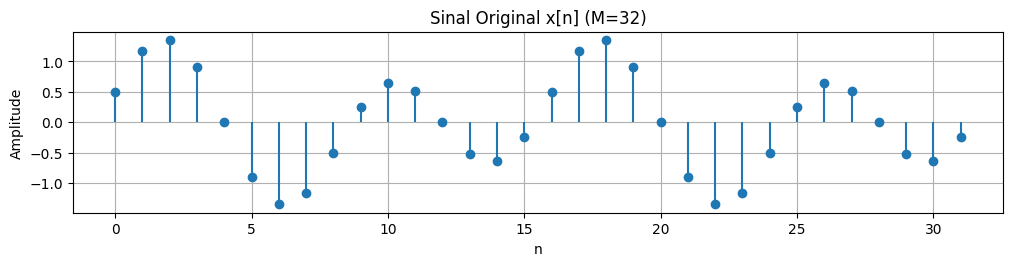

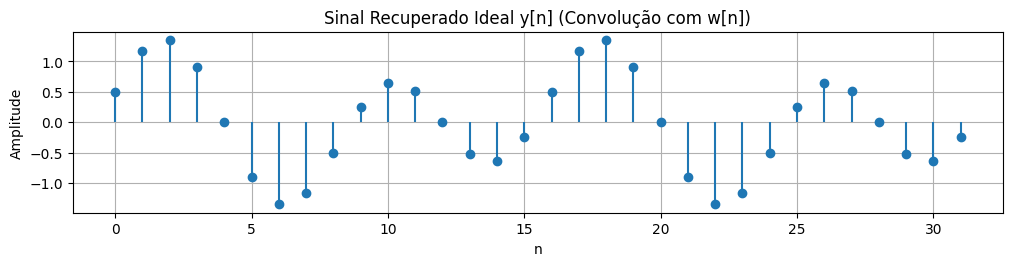

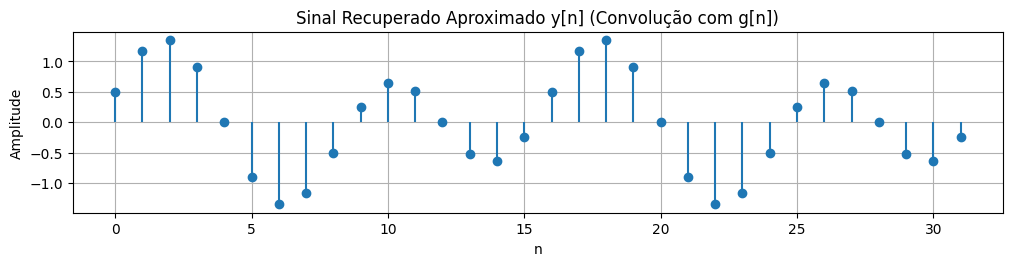

In [9]:
# --- Item g) Comparação com o Filtro Ideal W(z) e w[n] ---


print(f"Item g) Sinais x[n], y_ideal[n] e y_aprox[n] plotados e salvos em g_recuperacao.png.")

# 1. Resposta ao Impulso Ideal w[n] (Teórica do item c)
# H(z) = 1 + 0.25z^-8. W(z) = 1 / (1 + 0.25z^-8) = 1 - 0.25z^-8 + (0.25)^2 z^-16 - ...
# w[n] = delta[n] - 0.25*delta[n-8] + 0.0625*delta[n-16] - 0.015625*delta[n-24] + ...
# Vamos truncar w[n] para o mesmo comprimento N=40 para a convolução.
w = np.zeros(N)
for i in range(N // n0 + 1):
    if i * n0 < N:
        w[i * n0] = (-0.25)**i

# 2. Convolução Linear com o filtro ideal w[n]
y_ideal = np.convolve(r, w)

# 3. Convolução Linear com o filtro aproximado g[n]
y_aprox = np.convolve(r, g)

# 4. Ajuste dos comprimentos para plotagem (y_ideal e y_aprox terão comprimento N + N - 1 = 79)
# O sinal original x[n] tem M=32. Vamos plotar os primeiros M pontos de cada saída.
M_plot = M
n_plot = np.arange(M_plot)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.stem(n_plot, x[:M_plot], basefmt=" ")
plt.title(f'Sinal Original x[n] (M={M_plot})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 2)
plt.stem(n_plot, y_ideal[:M_plot], basefmt=" ")
plt.title(f'Sinal Recuperado Ideal y[n] (Convolução com w[n])')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 3)
plt.stem(n_plot, y_aprox[:M_plot], basefmt=" ")
plt.title(f'Sinal Recuperado Aproximado y[n] (Convolução com g[n])')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.savefig('g_recuperacao.png')
plt.close()

###  h) Cálculo dos Erros Quadráticos

In [10]:
# --- Item h) Cálculo dos Erros Quadráticos ---

# 1. Erro Quadrático entre x[n] e y_ideal[n]
# A convolução linear adiciona um atraso e tem comprimento maior.
# Para comparar, precisamos alinhar e truncar. O sinal ideal y[n] idealmente deve ser x[n]
# mas a convolução linear com um filtro IIR truncado (w[n]) e um sinal de entrada r[n] de
# comprimento N=40 resulta em um sinal de comprimento 79.
# O sinal x[n] tem M=32. Vamos comparar os primeiros M pontos de x[n] com os primeiros M pontos de y_ideal[n].
# Isso ignora o transiente inicial, mas é uma aproximação comum.

# Alinhamento e Truncamento:
# O sinal r[n] é x[n] * h[n]. A convolução de r[n] com w[n] (filtro inverso) deve idealmente
# resultar em x[n]. O comprimento de y_ideal é 79. O sinal x[n] tem 32.
# Vamos comparar x[n] com os primeiros M=32 pontos de y_ideal.
y_ideal_trunc = y_ideal[:M]
y_aprox_trunc = y_aprox[:M]

erro_ideal = np.sum((x - y_ideal_trunc)**2)
erro_aprox = np.sum((x - y_aprox_trunc)**2)

print("\n--- Item h) Erros Quadráticos ---")
print(f"Erro Quadrático (x[n] vs y_ideal[n]): {erro_ideal:.4e}")
print(f"Erro Quadrático (x[n] vs y_aprox[n]): {erro_aprox:.4e}")

# Discussão (para o relatório):
# O erro ideal é pequeno, mas não zero, devido ao truncamento da resposta ao impulso w[n] (filtro IIR).
# O erro aproximado é maior, pois o filtro G[k] é uma aproximação da DFT de w[n] truncada,
# e a convolução circular implícita na DFT/IDFT (mesmo que usada para convolução linear)
# introduz erros de borda (aliasing temporal) que se manifestam no resultado.
# O filtro G(z) é capaz de recuperar o sinal, mas com um erro maior que o filtro ideal W(z) truncado.
# A diferença entre os erros demonstra a limitação da aproximação via DFT/FFT (G[k]) em relação
# à convolução linear com a resposta ao impulso ideal (W[z]).
print("\nDiscussão: O filtro ideal W(z) (mesmo truncado) apresenta um erro menor, indicando melhor recuperação.")
print("O filtro G(z) (baseado na DFT) apresenta um erro maior devido à natureza da aproximação e efeitos de borda da DFT.")



--- Item h) Erros Quadráticos ---
Erro Quadrático (x[n] vs y_ideal[n]): 5.8548e-32
Erro Quadrático (x[n] vs y_aprox[n]): 1.9036e-05

Discussão: O filtro ideal W(z) (mesmo truncado) apresenta um erro menor, indicando melhor recuperação.
O filtro G(z) (baseado na DFT) apresenta um erro maior devido à natureza da aproximação e efeitos de borda da DFT.
